# Notebook 03: Exploratory Data Analysis

EDA of the final county-year feature dataset before vulnerability score construction.

## 1. Setup and Data Loading

In [1]:
# ==================================================
# Step 1: Setup and Data Loading
# ==================================================

# Import Libraries

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120


# Configure Paths

def find_project_root(start_path=None):
    """
    Find project root by searching upward for the data folder.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "data").exists():
            return path

    raise FileNotFoundError("Project root not found. Expected a folder containing 'data'.")


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"

COUNTY_YEAR_DATA_PATH = (
    INTERIM_DIR
    / "county_year_features"
    / "county_year_housing_spatial_disaster_acs_nfip_features.csv"
)

SHAPEFILE_PATH = (
    RAW_DIR
    / "shapefiles"
    / "tl_2025_us_county"
    / "tl_2025_us_county.shp"
)

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures" / "eda"
TABLES_DIR = RESULTS_DIR / "tables" / "eda"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("County-year data:", COUNTY_YEAR_DATA_PATH)
print("Shapefile:", SHAPEFILE_PATH)


# Load County-Year Dataset

county_year_df = pd.read_csv(COUNTY_YEAR_DATA_PATH)

print("County-year dataset loaded.")
print(f"Shape: {county_year_df.shape[0]:,} rows × {county_year_df.shape[1]:,} columns")

display(county_year_df.head())


# Validate Dataset Structure

validation_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique counties",
        "Start year",
        "End year",
        "Duplicate county-year rows",
        "Total missing values"
    ],
    "Value": [
        county_year_df.shape[0],
        county_year_df.shape[1],
        county_year_df["RegionName"].nunique(),
        county_year_df["Year"].min(),
        county_year_df["Year"].max(),
        county_year_df.duplicated(subset=["RegionName", "Year"]).sum(),
        county_year_df.isna().sum().sum()
    ]
})

display(validation_summary)

missing_summary = (
    county_year_df
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(county_year_df) * 100
)

missing_summary = missing_summary.sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])


# Load Florida County Shapefile

county_shapes = gpd.read_file(SHAPEFILE_PATH)

florida_shapes = county_shapes[county_shapes["STATEFP"] == "12"].copy()
florida_shapes["STCOFIPS"] = florida_shapes["GEOID"].astype(int)

print("Florida county shapefile loaded.")
print(f"Shape: {florida_shapes.shape[0]:,} counties × {florida_shapes.shape[1]:,} columns")
print("CRS:", florida_shapes.crs)

display(florida_shapes[["STCOFIPS", "NAME", "GEOID", "geometry"]].head())


# Validate Merge Keys

data_counties = set(county_year_df["STCOFIPS"].unique())
shape_counties = set(florida_shapes["STCOFIPS"].unique())

missing_from_shapes = sorted(data_counties - shape_counties)
missing_from_data = sorted(shape_counties - data_counties)

print("Merge key validation:")
print(f"Counties in county-year dataset: {len(data_counties)}")
print(f"Counties in Florida shapefile: {len(shape_counties)}")
print(f"County FIPS in data but not shapefile: {missing_from_shapes}")
print(f"County FIPS in shapefile but not data: {missing_from_data}")

Project root: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation
County-year data: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\data\interim\county_year_features\county_year_housing_spatial_disaster_acs_nfip_features.csv
Shapefile: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\data\raw\shapefiles\tl_2025_us_county\tl_2025_us_county.shp
County-year dataset loaded.
Shape: 1,000 rows × 75 columns


,STCOFIPS,RegionID,RegionName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,COUNTY,Year,avg_annual_housing_price,median_annual_housing_price,min_annual_housing_price,max_annual_housing_price,annual_price_volatility,monthly_observations,is_metro,SizeRank,POPULATION,CFLD_RISKS,HRCN_RISKS,SOVI_SCORE,RESL_SCORE,prev_year_housing_price,annual_price_growth_dollar,annual_price_growth_pct,baseline_housing_price,appreciation_from_baseline_pct,price_growth_acceleration,high_growth_flag,high_volatility_flag,complete_year_flag,neighbor_count,neighbor_avg_housing_price,neighbor_avg_price_growth_pct,neighbor_avg_price_volatility,neighbor_high_growth_share,neighbor_high_volatility_share,disaster_count,unique_disaster_events,climate_disaster_count,hurricane_disaster_count,tropical_storm_disaster_count,severe_storm_disaster_count,flood_disaster_count,fire_disaster_count,any_disaster_flag,any_climate_disaster_flag,cumulative_disaster_count,cumulative_climate_disaster_count,recent_3yr_disaster_count,recent_3yr_climate_disaster_count,acs_total_population,median_household_income,poverty_rate,unemployment_rate,owner_occupied_share,renter_occupied_share,median_gross_rent,acs_median_home_value,price_to_income_ratio,acs_estimated_2025_flag,nfip_claim_count,nfip_policy_count_sum,nfip_total_building_payment,nfip_total_contents_payment,nfip_total_icc_payment,nfip_total_claim_payment,nfip_avg_claim_payment,nfip_total_building_coverage,nfip_total_contents_coverage,nfip_cumulative_claim_count,nfip_cumulative_claim_payment,nfip_recent_3yr_claim_count,nfip_recent_3yr_claim_payment,nfip_claim_year_indicator
0,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2011,"144,811.6070","144,342.9672","140,135.5499","151,065.3041","4,024.2825",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"162,126.8332","-17,315.2262",-10.6800,"162,126.8332",-10.6800,NaN,0.0000,1,1,7,"102,374.8496",-6.7638,"1,794.8931",0.0000,0.1429,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"246,203.0000","41,373.0000",23.5571,7.3324,54.4678,45.5322,880.0000,"185,100.0000",3.5001,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
1,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2012,"136,832.4264","136,443.4221","134,664.5101","139,626.3387","1,809.8869",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"144,811.6070","-7,979.1805",-5.5100,"162,126.8332",-15.6016,5.1700,0.0000,0,1,7,"99,827.4856",-2.4554,"1,117.2797",0.0000,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"247,973.0000","42,818.0000",23.7840,7.8659,55.3167,44.6833,895.0000,"176,300.0000",3.1957,0,10.0000,10.0000,"200,195.9800",0.0000,0.0000,"200,195.9800","20,019.5980","1,767,900.0000","448,500.0000",10.0000,"200,195.9800",10.0000,"200,195.9800",1
2,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2013,"140,015.1495","140,678.1221","136,740.2372","141,791.3858","1,500.6978",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"136,832.4264","3,182.7231",2.3260,"162,126.8332",-13.6385,7.8360,0.0000,0,1,7,"102,229.3017",2.3680,"1,412.4035",0.1429,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"249,848.0000","42,149.0000",24.9005,8.6407,54.1445,45.8555,886.0000,"167,900.0000",3.3219,0,3.0000,3.0000,"5,630.4300",0.0000,0.0000,"5,630.4300","1,876.8100","376,000.0000","132,100.0000",13.0000,"205,826.4100",13.0000,"205,826.4100",1
3,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2014,"147,354.5217","148,554.6110","142,716.3982","149,219.2739","2,125.8359",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"140,015.1495","7,339.3722",5.2418,"162,126.8332",-9.1116,2.9158,0.0000,0,1,7,"106,775.5555",4.3319,"1,637.6729",0.1429,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"251,759.0000","42,045.0000",25.3621,8.5354,53.5403,46.4597,883.0000,"164,600.0000",3.5047,0,2.0000,2.0000,"12,849.4900",0.0000,0.0000,"12,849.4900","6,424.7450","500,000.0000","200,000.0000",15.0000,"218,675.9000",15.0000,"218,675.9000",1
4,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2015,"153,750.1221","153,513.3196","149,742.2103","15

,Metric,Value
0,Rows,1000
1,Columns,75
2,Unique counties,67
3,Start year,2011
4,End year,2025
5,Duplicate county-year rows,0
6,Total missing values,82


,column,missing_count,missing_pct
27,price_growth_acceleration,70,7.0000
23,annual_price_growth_dollar,3,0.3000
22,prev_year_housing_price,3,0.3000
24,annual_price_growth_pct,3,0.3000
28,high_growth_flag,3,0.3000


Florida county shapefile loaded.
Shape: 67 counties × 20 columns
CRS: EPSG:4269


,STCOFIPS,NAME,GEOID,geometry
22,12045,Gulf,12045,"POLYGON ((-85.39126 30.02816, -85.39123 30.028..."
46,12105,Polk,12105,"POLYGON ((-81.42455 28.01248, -81.42455 28.012..."
93,12079,Madison,12079,"POLYGON ((-83.82191 30.30749, -83.8219 30.3076..."
173,12029,Dixie,12029,"MULTIPOLYGON (((-82.91871 29.82408, -82.91672 ..."
187,12097,Osceola,12097,"POLYGON ((-81.65727 28.3471, -81.65666 28.3471..."


Merge key validation:
Counties in county-year dataset: 67
Counties in Florida shapefile: 67
County FIPS in data but not shapefile: []
County FIPS in shapefile but not data: []


### 1.1 Helper Functions

In [3]:
# ==================================================
# Step 1.1: Helper Functions
# ==================================================

# Save current figure

def save_figure(filename, dpi=300):
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {output_path}")


# Save dataframe as CSV

def save_table(df, filename):
    output_path = TABLES_DIR / filename
    df.to_csv(output_path, index=False)
    print(f"Table saved to: {output_path}")


# Format axis as currency

def format_currency_axis(axis):
    axis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"${x:,.0f}")
    )


# Format axis as percentage

def format_percent_axis(axis):
    axis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{x:.0f}%")
    )

Step 1 Key Takeaways

The dataset was loaded successfully with 1,000 county-year observations, 75 variables, and coverage across 67 Florida counties from 2011 to 2025. The dataset contains no duplicate county-year records, which confirms that each county-year combination is represented only once.

The Florida county shapefile also contains 67 counties, and the merge-key validation shows that all county FIPS codes in the feature dataset match the shapefile. This confirms that the dataset is ready for county-level spatial analysis.

The remaining missing values are limited to lag-based and growth-acceleration variables, mainly because some indicators depend on previous-year values. These missing values do not affect the main EDA feature groups used for mapping and descriptive analysis.

## 2. Dataset Overview and Descriptive Summary

Summarize dataset coverage, variable groups, descriptive statistics, and top counties by selected indicators.

### 2.1 Coverage Summary

### 2.2 Variable Group Summary

### 2.3 Descriptive Statistics

### 2.4 Top County Summary

In [4]:
# ==================================================
# Step 2: Dataset Overview and Descriptive Summary
# ==================================================

# Coverage Summary

coverage_summary = pd.DataFrame({
    "Metric": [
        "Total county-year observations",
        "Number of counties",
        "Study period",
        "Number of years",
        "Duplicate county-year rows",
        "Total columns",
        "Total missing values"
    ],
    "Value": [
        f"{county_year_df.shape[0]:,}",
        county_year_df["RegionName"].nunique(),
        f"{county_year_df['Year'].min()}–{county_year_df['Year'].max()}",
        county_year_df["Year"].nunique(),
        county_year_df.duplicated(subset=["RegionName", "Year"]).sum(),
        county_year_df.shape[1],
        county_year_df.isna().sum().sum()
    ]
})

display(coverage_summary)
save_table(coverage_summary, "eda_coverage_summary.csv")


# Variable Group Summary

variable_groups = {
    "Housing Market": [
        "avg_annual_housing_price",
        "median_annual_housing_price",
        "annual_price_growth_pct",
        "appreciation_from_baseline_pct",
        "annual_price_volatility",
        "price_growth_acceleration"
    ],
    "Climate Exposure": [
        "CFLD_RISKS",
        "HRCN_RISKS"
    ],
    "Disaster History": [
        "disaster_count",
        "climate_disaster_count",
        "hurricane_disaster_count",
        "cumulative_climate_disaster_count",
        "recent_3yr_climate_disaster_count"
    ],
    "Socioeconomic and Affordability": [
        "SOVI_SCORE",
        "median_household_income",
        "poverty_rate",
        "unemployment_rate",
        "renter_occupied_share",
        "price_to_income_ratio"
    ],
    "Resilience": [
        "RESL_SCORE"
    ],
    "NFIP Insurance Loss": [
        "nfip_claim_count",
        "nfip_total_claim_payment",
        "nfip_avg_claim_payment",
        "nfip_cumulative_claim_payment",
        "nfip_recent_3yr_claim_payment"
    ],
    "Spatial Neighbor Features": [
        "neighbor_count",
        "neighbor_avg_housing_price",
        "neighbor_avg_price_growth_pct",
        "neighbor_avg_price_volatility",
        "neighbor_high_growth_share",
        "neighbor_high_volatility_share"
    ]
}

variable_group_summary = []

for group_name, columns in variable_groups.items():
    available_columns = [col for col in columns if col in county_year_df.columns]
    missing_columns = [col for col in columns if col not in county_year_df.columns]
    
    variable_group_summary.append({
        "Variable Group": group_name,
        "Available Variables": len(available_columns),
        "Missing Variables": len(missing_columns),
        "Columns Used": ", ".join(available_columns)
    })

variable_group_summary = pd.DataFrame(variable_group_summary)

display(variable_group_summary)
save_table(variable_group_summary, "eda_variable_group_summary.csv")


# Descriptive Statistics

summary_columns = [
    "avg_annual_housing_price",
    "annual_price_growth_pct",
    "appreciation_from_baseline_pct",
    "annual_price_volatility",
    "CFLD_RISKS",
    "HRCN_RISKS",
    "SOVI_SCORE",
    "RESL_SCORE",
    "cumulative_climate_disaster_count",
    "recent_3yr_climate_disaster_count",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "renter_occupied_share",
    "price_to_income_ratio",
    "nfip_cumulative_claim_payment",
    "nfip_recent_3yr_claim_payment",
    "neighbor_avg_price_growth_pct"
]

summary_columns = [col for col in summary_columns if col in county_year_df.columns]

descriptive_summary = (
    county_year_df[summary_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)

display(descriptive_summary)
save_table(descriptive_summary, "eda_descriptive_statistics.csv")


# County-Level Summary for Top County Tables

county_summary = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        avg_housing_price=("avg_annual_housing_price", "mean"),
        avg_annual_price_growth_pct=("annual_price_growth_pct", "mean"),
        total_appreciation_from_baseline_pct=("appreciation_from_baseline_pct", "max"),
        flood_risk=("CFLD_RISKS", "mean"),
        hurricane_risk=("HRCN_RISKS", "mean"),
        social_vulnerability=("SOVI_SCORE", "mean"),
        resilience=("RESL_SCORE", "mean"),
        cumulative_climate_disasters=("cumulative_climate_disaster_count", "max"),
        cumulative_nfip_claim_payment=("nfip_cumulative_claim_payment", "max"),
        avg_price_to_income_ratio=("price_to_income_ratio", "mean")
    )
)

top_growth_counties = (
    county_summary
    .sort_values("avg_annual_price_growth_pct", ascending=False)
    .head(10)
)

top_disaster_counties = (
    county_summary
    .sort_values("cumulative_climate_disasters", ascending=False)
    .head(10)
)

top_nfip_counties = (
    county_summary
    .sort_values("cumulative_nfip_claim_payment", ascending=False)
    .head(10)
)

top_sovi_counties = (
    county_summary
    .sort_values("social_vulnerability", ascending=False)
    .head(10)
)

print("Top 10 counties by average annual price growth:")
display(top_growth_counties)

print("Top 10 counties by cumulative climate disaster count:")
display(top_disaster_counties)

print("Top 10 counties by cumulative NFIP claim payment:")
display(top_nfip_counties)

print("Top 10 counties by social vulnerability:")
display(top_sovi_counties)


# Save Top County Tables

save_table(county_summary, "eda_county_level_summary.csv")
save_table(top_growth_counties, "eda_top_growth_counties.csv")
save_table(top_disaster_counties, "eda_top_disaster_counties.csv")
save_table(top_nfip_counties, "eda_top_nfip_counties.csv")
save_table(top_sovi_counties, "eda_top_social_vulnerability_counties.csv")

,Metric,Value
0,Total county-year observations,"1,000"
1,Number of counties,67
2,Study period,2011–2025
3,Number of years,15
4,Duplicate county-year rows,0
5,Total columns,75
6,Total missing values,82


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_coverage_summary.csv


,Variable Group,Available Variables,Missing Variables,Columns Used
0,Housing Market,6,0,"avg_annual_housing_price, median_annual_housin..."
1,Climate Exposure,2,0,"CFLD_RISKS, HRCN_RISKS"
2,Disaster History,5,0,"disaster_count, climate_disaster_count, hurric..."
3,Socioeconomic and Affordability,6,0,"SOVI_SCORE, median_household_income, poverty_r..."
4,Resilience,1,0,RESL_SCORE
5,NFIP Insurance Loss,5,0,"nfip_claim_count, nfip_total_claim_payment, nf..."
6,Spatial Neighbor Features,6,0,"neighbor_count, neighbor_avg_housing_price, ne..."


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_variable_group_summary.csv


,Variable,count,mean,std,min,25%,50%,75%,max
0,avg_annual_housing_price,"1,000.0000","215,760.5413","118,805.1627","69,581.7537","128,794.8208","188,718.6455","272,562.1712","993,480.7284"
1,annual_price_growth_pct,997.0000,6.2899,7.9526,-14.0232,1.3444,5.9166,9.8704,35.7356
2,appreciation_from_baseline_pct,"1,000.0000",57.0451,61.6793,-19.5710,3.4145,39.7774,102.4123,267.0238
3,annual_price_volatility,"1,000.0000","5,510.0320","5,890.9728",161.5926,"2,161.4682","3,834.1378","6,172.3711","57,938.9219"
4,CFLD_RISKS,"1,000.0000",47.5360,37.7289,0.0000,0.0000,61.2000,78.5500,99.6000
5,HRCN_RISKS,"1,000.0000",94.0150,5.4356,74.4681,90.5715,94.9937,98.6650,99.9583
6,SOVI_SCORE,"1,000.0000",57.8004,23.4238,11.3868,39.8855,56.6794,75.8588,97.9008
7,RESL_SCORE,"1,000.0000",32.3449,22.8982,0.6679,10.9097,29.4529,47.7735,96.2786
8,cumulative_climate_disaster_count,"1,000.0000",6.3580,6.1012,0.0000,1.0000,5.0000,10.0000,22.0000
9,recent_3yr_climate_disaster_count,"1,000.0000",3.2540,2.9220,0.0000,1.0000,3.0000,5.0000,13.0000


...

Top 10 counties by cumulative NFIP claim payment:


,STCOFIPS,RegionName,avg_housing_price,avg_annual_price_growth_pct,total_appreciation_from_baseline_pct,flood_risk,hurricane_risk,social_vulnerability,resilience,cumulative_climate_disasters,cumulative_nfip_claim_payment,avg_price_to_income_ratio
34,12071,Lee County,"250,705.2460",7.0817,195.9955,97.4000,99.9166,67.8435,8.7786,18,"3,878,871,800.6200",4.1627
51,12103,Pinellas County,"244,822.7489",6.9740,180.3996,99.2000,98.8736,59.9237,10.9097,20,"3,565,829,110.6600",4.2457
27,12057,Hillsborough County,"243,851.2516",7.2220,180.8420,92.4000,99.2908,36.3868,33.2379,20,"1,126,276,724.1100",3.9055
10,12021,Collier County,"390,870.2859",6.0838,143.0465,95.2000,99.7497,74.7137,41.2850,21,"1,114,534,735.9000",5.5035
57,12115,Sarasota County,"293,581.0080",6.3769,168.9405,93.6000,99.5411,67.0165,9.1921,19,"820,323,432.6200",4.5509
39,12081,Manatee County,"290,688.0891",6.7617,174.7815,98.0000,99.3325,54.8346,22.7735,21,"621,365,987.8700",4.7152
50,12101,Pasco County,"217,364.3822",6.6493,160.6784,90.8000,98.1227,39.6628,10.4326,20,"589,065,143.0300",3.8979
63,12127,Volusia County,"211,391.4384",6.7800,166.1907,85.0000,98.4564,56.6794,48.2824,17,"531,585,130.9800",3.9405
7,12015,Charlotte County,"226,283.9977",6.8741,196.6028,90.4000,98.9987,77.0038,12.1501,17,"461,155,716.8600",4.1263
5,12011,Broward County,"274,284.8928",7.7796,207.4352,97.0000,99.8331,55.3753,44.1794,14,"370,567,774.0300",4.3609


Top 10 counties by social vulnerability:


,STCOFIPS,RegionName,avg_housing_price,avg_annual_price_growth_pct,total_appreciation_from_baseline_pct,flood_risk,hurricane_risk,social_vulnerability,resilience,cumulative_climate_disasters,cumulative_nfip_claim_payment,avg_price_to_income_ratio
31,12065,Jefferson County,"185,540.7157",5.5033,117.9701,39.4000,86.7334,97.9008,32.1883,21,0.0000,3.7133
18,12039,Gadsden County,"127,588.5199",4.6479,93.1181,0.0000,91.4476,95.0382,33.8104,19,"121,509.4800",3.0650
26,12055,Highlands County,"141,732.0755",6.6562,155.9952,0.0000,95.7030,94.1158,5.6934,13,"2,033,213.8400",3.1887
36,12075,Levy County,"175,688.5702",6.5491,154.1945,72.6000,91.6145,93.4478,9.1603,21,"46,948,932.8900",4.0623
12,12027,De Soto County,"156,204.2014",7.3368,186.5448,33.4000,96.2453,90.8397,1.3995,15,"14,541,777.9600",3.7525
24,12051,Hendry County,"154,947.6040",9.2013,267.0238,25.6000,94.2428,90.2990,0.6679,12,"297,467.2200",3.4953
59,12119,Sumter County,"286,468.3009",4.8222,102.7800,0.0000,95.8281,90.0445,46.9784,18,"912,993.3300",4.8021
20,12043,Glades County,"148,245.0438",7.7053,193.7839,0.0000,87.6095,89.7265,0.9224,13,"112,178.5600",3.8037
61,12123,Taylor County,"125,259.8727",5.0422,109.0362,76.6000,92.6992,89.4084,26.7494,22,"33,483,471.6000",3.0380
22,12047,Hamilton County,"119,021.4089",6.3076,141.9427,0.0000,90.0709,89.0267,8.3969,19,"50,367.3000",2.8600


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_county_level_summary.csv
Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_top_growth_counties.csv
Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_top_disaster_counties.csv
Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_top_nfip_counties.csv
Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_top_social_vulnerability_counties.csv


### Step 2 Summary

The dataset covers 67 Florida counties from 2011 to 2025 with no duplicate county-year rows.

The feature groups needed for the EDA are available, including housing, climate exposure, disaster history, socioeconomic conditions, resilience, NFIP losses, and spatial-neighbor indicators.

The top-county summaries show early evidence that housing growth, disaster exposure, NFIP losses, and social vulnerability are not concentrated in only one type of county.

## 3. Housing Market Patterns

This section examines whether Florida housing prices continued to grow despite major disaster years.

### 3.1 Statewide Housing Price Trend

In [5]:
# ==================================================
# Step 3: Housing Market Patterns
# Figure 1 Data Preparation
# ==================================================

# Create statewide annual housing price summary

statewide_price_trend = (
    county_year_df
    .groupby("Year", as_index=False)
    .agg(
        statewide_avg_price=("avg_annual_housing_price", "mean"),
        county_min_price=("avg_annual_housing_price", "min"),
        county_max_price=("avg_annual_housing_price", "max")
    )
)

display(statewide_price_trend.head())

,Year,statewide_avg_price,county_min_price,county_max_price
0,2011,"123,820.6216","70,481.0005","246,556.2197"
1,2012,"122,216.8515","69,581.7537","247,305.2371"
2,2013,"131,230.9891","77,045.8534","274,275.7791"
3,2014,"142,503.3274","81,389.2629","301,363.8252"
4,2015,"152,479.7692","82,728.3011","324,694.5341"


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig01_statewide_housing_price_trend_event_markers.png


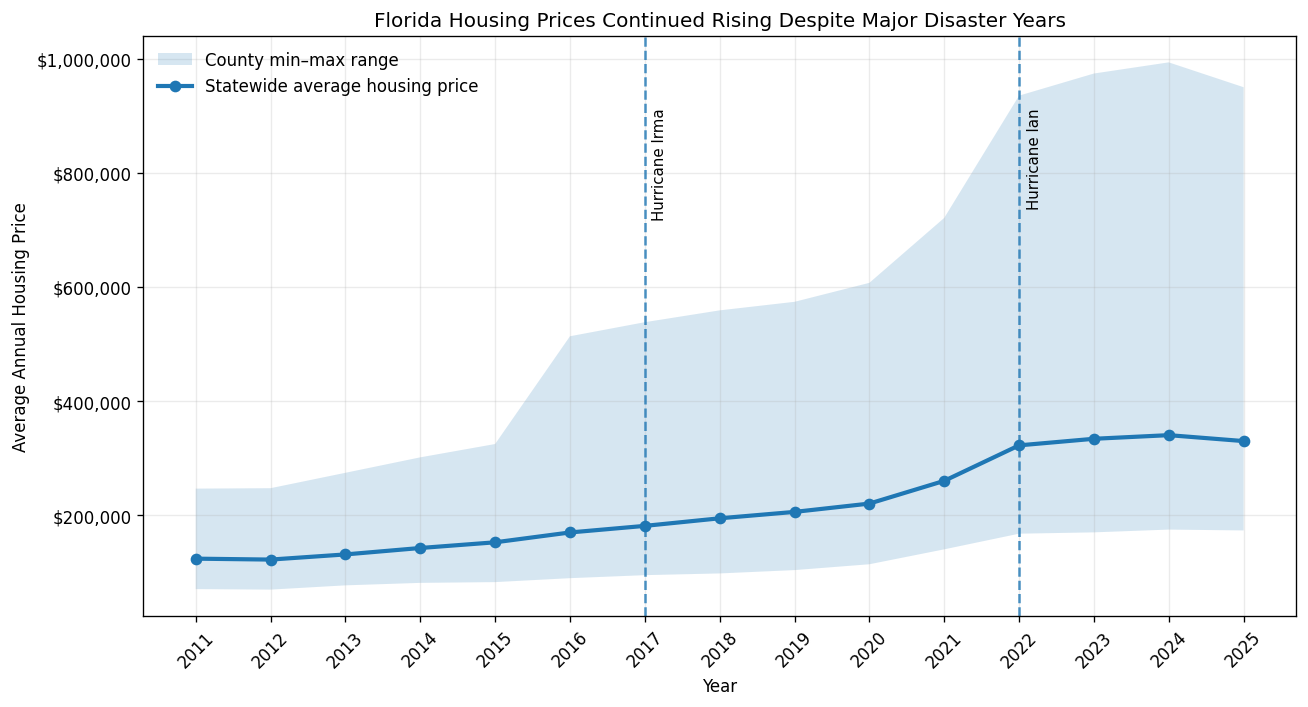

In [6]:
# ==================================================
# Step 3: Housing Market Patterns
# Figure 1 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(11, 6))

# Min-max county price band
ax.fill_between(
    statewide_price_trend["Year"],
    statewide_price_trend["county_min_price"],
    statewide_price_trend["county_max_price"],
    alpha=0.18,
    label="County min–max range"
)

# Statewide average line
ax.plot(
    statewide_price_trend["Year"],
    statewide_price_trend["statewide_avg_price"],
    linewidth=2.5,
    marker="o",
    label="Statewide average housing price"
)

# Disaster event markers
event_years = {
    2017: "Hurricane Irma",
    2022: "Hurricane Ian"
}

for year, label in event_years.items():
    ax.axvline(
        x=year,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8
    )
    
    ax.text(
        year + 0.1,
        statewide_price_trend["county_max_price"].max() * 0.92,
        label,
        rotation=90,
        va="top",
        fontsize=9
    )

# Labels and formatting
ax.set_title("Florida Housing Prices Continued Rising Despite Major Disaster Years")
ax.set_xlabel("Year")
ax.set_ylabel("Average Annual Housing Price")
ax.set_xticks(statewide_price_trend["Year"])
ax.tick_params(axis="x", rotation=45)

format_currency_axis(ax.yaxis)

ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)

plt.tight_layout()
save_figure("fig01_statewide_housing_price_trend_event_markers.png")
plt.show()

### Figure 1 Interpretation

* Florida’s average annual housing price increased from about **$123,821 in 2011** to **$329,862 in 2025**, showing strong long-term market growth.

* The shaded county range widens over time, showing that housing values became more uneven across Florida counties.

* Major hurricane years, including **Irma 2017** and **Ian 2022**, did not interrupt the broader upward statewide trend.

* This supports the main EDA motivation: rising prices do not necessarily mean lower vulnerability. Climate-related stress may still exist beneath a strong housing market.


### 3.2 County-Level Price Growth

In [7]:
# ==================================================
# Step 3: Housing Market Patterns
# Figure 2 Data Preparation
# ==================================================

# Create county-level housing growth summary

county_price_growth = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        avg_annual_price_growth_pct=("annual_price_growth_pct", "mean"),
        total_appreciation_from_baseline_pct=("appreciation_from_baseline_pct", "max"),
        avg_annual_housing_price=("avg_annual_housing_price", "mean")
    )
)

# Merge with Florida county geometry

price_growth_map = florida_shapes.merge(
    county_price_growth,
    on="STCOFIPS",
    how="left"
)

print("Price growth map dataset created.")
print(f"Shape: {price_growth_map.shape}")
print(f"Missing average annual price growth values: {price_growth_map['avg_annual_price_growth_pct'].isna().sum()}")

display(
    county_price_growth
    .sort_values("avg_annual_price_growth_pct", ascending=False)
    .head(10)
)

Price growth map dataset created.
Shape: (67, 24)
Missing average annual price growth values: 0


,STCOFIPS,RegionName,avg_annual_price_growth_pct,total_appreciation_from_baseline_pct,avg_annual_housing_price
24,12051,Hendry County,9.2013,267.0238,"154,947.6040"
55,12111,Saint Lucie County,9.1307,266.9735,"229,315.0414"
42,12086,Miami-Dade County,8.0260,212.0169,"318,826.6706"
48,12097,Osceola County,7.8589,208.1973,"240,178.9741"
46,12093,Okeechobee County,7.8526,200.9842,"161,002.2344"
5,12011,Broward County,7.7796,207.4352,"274,284.8928"
20,12043,Glades County,7.7053,193.7839,"148,245.0438"
43,12087,Monroe County,7.4840,93.4641,"736,500.2358"
47,12095,Orange County,7.3576,186.0998,"259,858.5266"
25,12053,Hernando County,7.3503,179.2829,"187,998.9016"


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig02_county_average_annual_price_growth_map.png


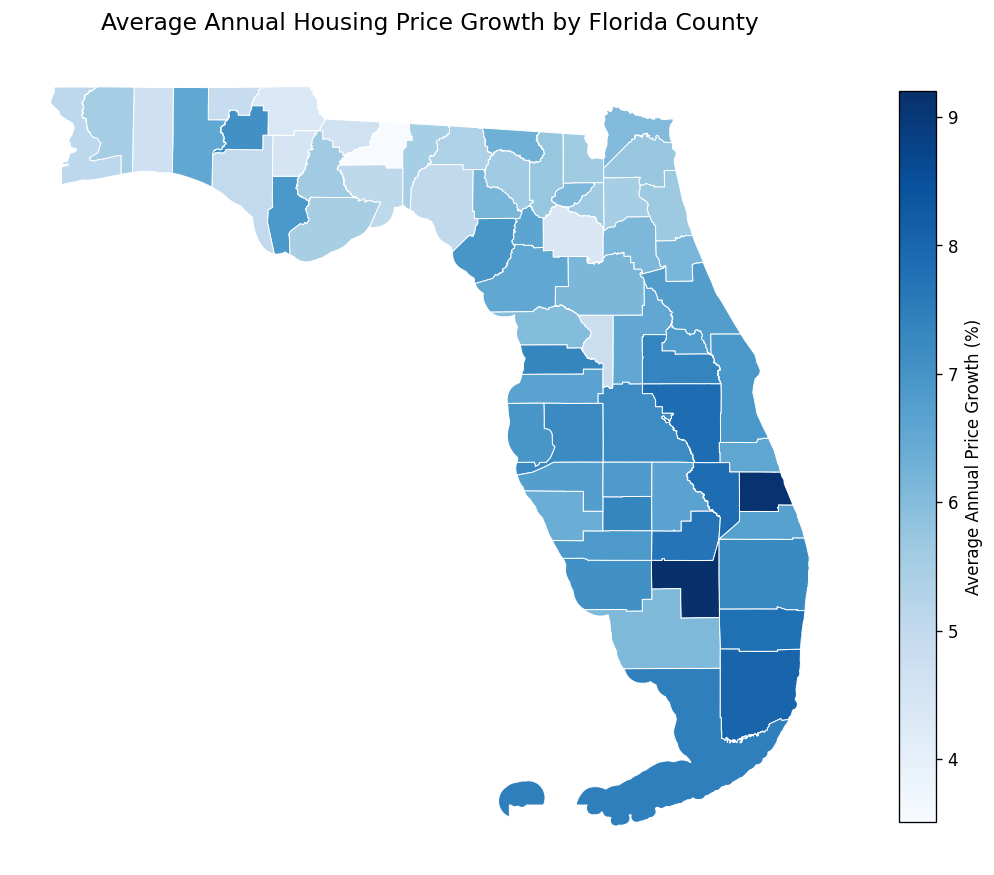

In [9]:
# ==================================================
# Step 3: Housing Market Patterns
# Figure 2 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(9, 9))

price_growth_map.plot(
    column="avg_annual_price_growth_pct",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Average Annual Price Growth (%)",
        "shrink": 0.7
    }
)

ax.set_title("Average Annual Housing Price Growth by Florida County", fontsize=14, pad=12)
ax.axis("off")

plt.tight_layout()
save_figure("fig02_county_average_annual_price_growth_map.png")
plt.show()

### Figure 2 Interpretation

* Average annual price growth is spatially uneven across Florida counties.

* High-growth counties include coastal and metro markets such as **Miami-Dade, Broward, Monroe, Saint Lucie, and Orange**.

* Strong growth also appears in inland and south-central counties such as **Hendry, Okeechobee, Glades, and Osceola**.

* This shows that housing-market pressure is not limited to one county type.

* The map supports the hidden-risk framing: counties with strong price growth may still face climate exposure, disaster history, affordability stress, insurance losses, or socioeconomic vulnerability.

### Step 3 Key Takeaways

* Florida’s average annual housing price increased from about **$123,821 in 2011** to **$329,862 in 2025**, showing strong long-term market growth.

* Major hurricane years did not reverse the statewide trend. Prices continued rising around **Irma 2017** and **Ian 2022**.

* Growth was spatially uneven. By 2025, county averages ranged from about **$173,253 in Jackson County** to **$949,933 in Monroe County**.

* High-growth counties included a mix of coastal, metro, and inland markets, such as **Miami-Dade, Broward, Monroe, Saint Lucie, Osceola, Hendry, Glades, and Okeechobee**.

* These patterns show that housing-market strength is visible, but uneven. Price growth alone does not explain the climate, disaster, insurance, affordability, and socioeconomic pressures behind vulnerability.


## 4. Social Vulnerability and Resilience

This section examines how social vulnerability and resilience vary across Florida counties.

### 4.1 Social Vulnerability × Resilience Map

In [10]:
# ==================================================
# Step 4: Social Vulnerability and Resilience
# Figure 3 Data Preparation
# ==================================================

# Import legend patch for custom map legend

from matplotlib.patches import Patch


# Create county-level social vulnerability and resilience summary

county_social_resilience = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        social_vulnerability=("SOVI_SCORE", "mean"),
        resilience=("RESL_SCORE", "mean")
    )
)


# Create median thresholds

sovi_median = county_social_resilience["social_vulnerability"].median()
resilience_median = county_social_resilience["resilience"].median()


# Classify counties into high/low social vulnerability and high/low resilience

county_social_resilience["sovi_group"] = np.where(
    county_social_resilience["social_vulnerability"] >= sovi_median,
    "High social vulnerability",
    "Low social vulnerability"
)

county_social_resilience["resilience_group"] = np.where(
    county_social_resilience["resilience"] >= resilience_median,
    "High resilience",
    "Low resilience"
)


# Create bivariate category

county_social_resilience["sovi_resilience_category"] = (
    county_social_resilience["sovi_group"]
    + " + "
    + county_social_resilience["resilience_group"]
)


# Merge with Florida county geometry

sovi_resilience_map = florida_shapes.merge(
    county_social_resilience,
    on="STCOFIPS",
    how="left"
)

print("Social vulnerability and resilience map dataset created.")
print(f"Shape: {sovi_resilience_map.shape}")
print(f"Missing category values: {sovi_resilience_map['sovi_resilience_category'].isna().sum()}")

display(
    county_social_resilience
    .sort_values("social_vulnerability", ascending=False)
    .head(10)
)

Social vulnerability and resilience map dataset created.
Shape: (67, 26)
Missing category values: 0


,STCOFIPS,RegionName,social_vulnerability,resilience,sovi_group,resilience_group,sovi_resilience_category
31,12065,Jefferson County,97.9008,32.1883,High social vulnerability,High resilience,High social vulnerability + High resilience
18,12039,Gadsden County,95.0382,33.8104,High social vulnerability,High resilience,High social vulnerability + High resilience
26,12055,Highlands County,94.1158,5.6934,High social vulnerability,Low resilience,High social vulnerability + Low resilience
36,12075,Levy County,93.4478,9.1603,High social vulnerability,Low resilience,High social vulnerability + Low resilience
12,12027,De Soto County,90.8397,1.3995,High social vulnerability,Low resilience,High social vulnerability + Low resilience
24,12051,Hendry County,90.2990,0.6679,High social vulnerability,Low resilience,High social vulnerability + Low resilience
59,12119,Sumter County,90.0445,46.9784,High social vulnerability,High resilience,High social vulnerability + High resilience
20,12043,Glades County,89.7265,0.9224,High social vulnerability,Low resilience,High social vulnerability + Low resilience
61,12123,Taylor County,89.4084,26.7494,High social vulnerability,Low resilience,High social vulnerability + Low resilience
22,12047,Hamilton County,89.0267,8.3969,High social vulnerability,Low resilience,High social vulnerability + Low resilience


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig03_social_vulnerability_resilience_bivariate_map.png


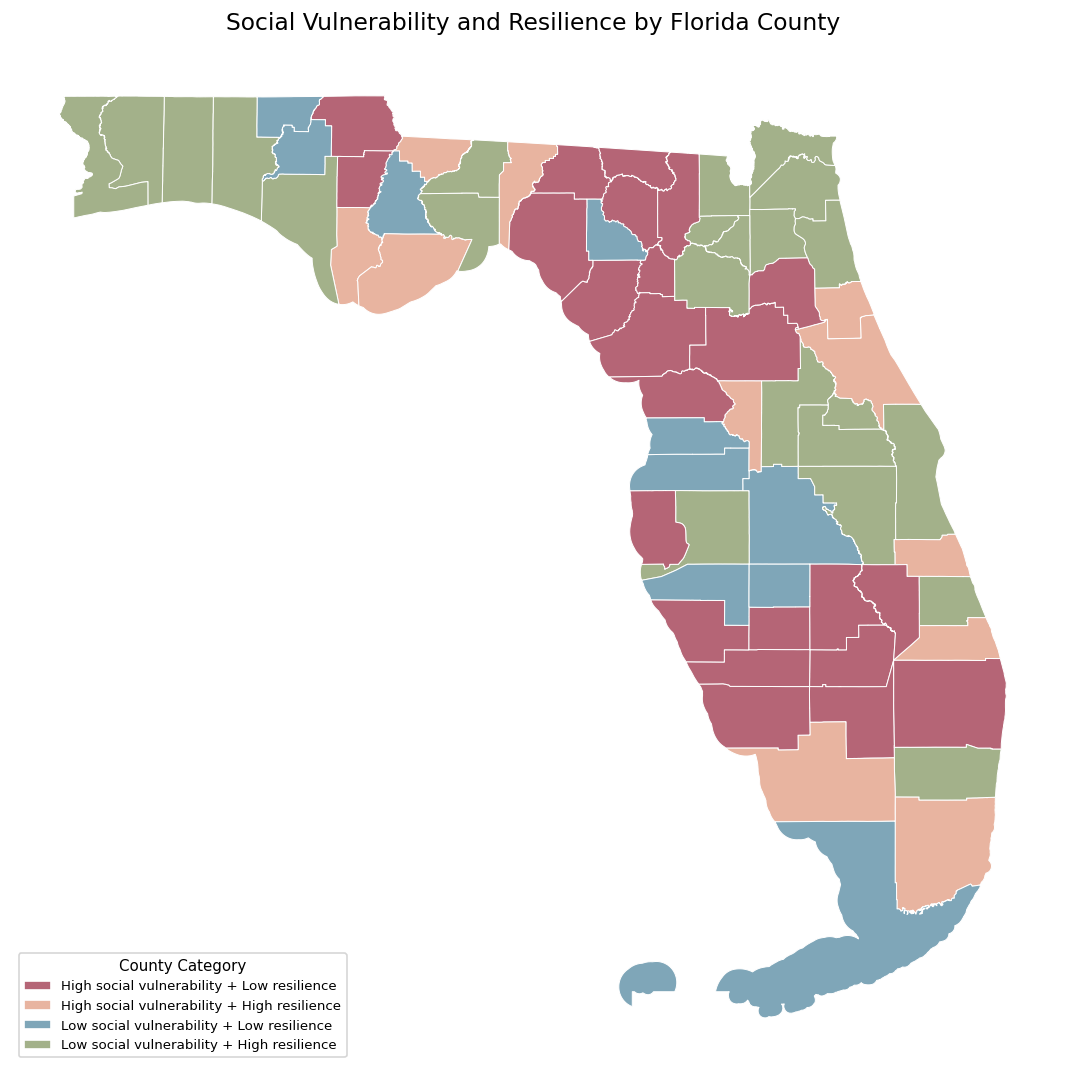

In [17]:
# ==================================================
# Step 4: Social Vulnerability and Resilience
# Figure 3 Visualization
# ==================================================

# Define professional muted bivariate colors

category_colors = {
    "High social vulnerability + Low resilience": "#B56576",   # muted mauve-red
    "High social vulnerability + High resilience": "#E8B4A0",  # pale salmon
    "Low social vulnerability + Low resilience": "#7FA6B8",    # coastal blue-gray
    "Low social vulnerability + High resilience": "#A3B18A"    # muted olive green
}

sovi_resilience_map["map_color"] = (
    sovi_resilience_map["sovi_resilience_category"]
    .map(category_colors)
)

fig, ax = plt.subplots(figsize=(9, 9))

sovi_resilience_map.plot(
    color=sovi_resilience_map["map_color"],
    linewidth=0.6,
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Social Vulnerability and Resilience by Florida County",
    fontsize=14,
    pad=12
)

ax.axis("off")

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="white",
        label=label
    )
    for label, color in category_colors.items()
]

ax.legend(
    handles=legend_handles,
    title="County Category",
    loc="lower left",
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
save_figure("fig03_social_vulnerability_resilience_bivariate_map.png")
plt.show()

### Figure 3 Interpretation

* This bivariate map shows how **social vulnerability** and **resilience** combine across Florida counties.

* The key pattern is that vulnerability and resilience are **not simple opposites**. Counties can fall into different combinations, such as high social vulnerability with low resilience or high social vulnerability with higher resilience.

* The most concerning counties are those with **high social vulnerability + low resilience**, because they may have fewer resources to absorb or recover from climate and housing-market stress.

* This figure supports the multi-dimensional framework by showing that social vulnerability and resilience should be treated as **separate components**, not merged into one general risk measure.

### 4.2 Socioeconomic Vulnerability Map

In [18]:
# ==================================================
# Step 4: Social Vulnerability and Resilience
# Figure 4 Data Preparation
# ==================================================

# Create county-level social vulnerability summary

county_sovi = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        social_vulnerability=("SOVI_SCORE", "mean"),
        poverty_rate=("poverty_rate", "mean"),
        unemployment_rate=("unemployment_rate", "mean"),
        renter_occupied_share=("renter_occupied_share", "mean")
    )
)

# Merge with Florida county geometry

sovi_map = florida_shapes.merge(
    county_sovi,
    on="STCOFIPS",
    how="left"
)

print("Socioeconomic vulnerability map dataset created.")
print(f"Shape: {sovi_map.shape}")
print(f"Missing social vulnerability values: {sovi_map['social_vulnerability'].isna().sum()}")

display(
    county_sovi
    .sort_values("social_vulnerability", ascending=False)
    .head(10)
)

Socioeconomic vulnerability map dataset created.
Shape: (67, 25)
Missing social vulnerability values: 0


,STCOFIPS,RegionName,social_vulnerability,poverty_rate,unemployment_rate,renter_occupied_share
31,12065,Jefferson County,97.9008,17.4221,8.6158,23.8944
18,12039,Gadsden County,95.0382,26.2702,8.3740,28.4424
26,12055,Highlands County,94.1158,17.6826,10.3895,22.7626
36,12075,Levy County,93.4478,20.2737,8.2639,21.7060
12,12027,De Soto County,90.8397,27.1108,9.0205,28.7532
24,12051,Hendry County,90.2990,25.1724,9.3555,30.5351
59,12119,Sumter County,90.0445,9.9366,7.4397,10.9025
20,12043,Glades County,89.7265,20.2627,10.4576,21.7807
61,12123,Taylor County,89.4084,17.1958,8.0953,22.2169
22,12047,Hamilton County,89.0267,25.9052,12.0637,26.2349


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig04_socioeconomic_vulnerability_map.png


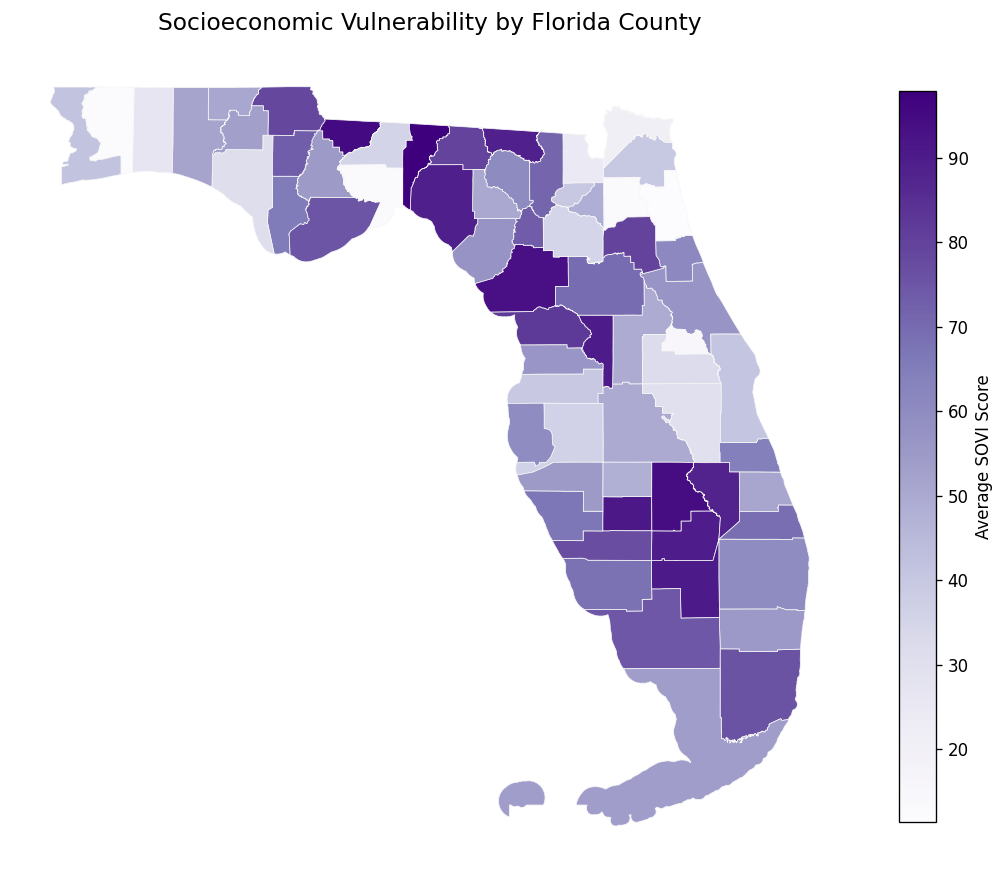

In [20]:
# ==================================================
# Step 4: Social Vulnerability and Resilience
# Figure 4 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(9, 9))

sovi_map.plot(
    column="social_vulnerability",
    cmap="Purples",
    linewidth=0.45,
    edgecolor="#F7F7F7",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Average SOVI Score",
        "shrink": 0.7
    }
)

ax.set_title(
    "Socioeconomic Vulnerability by Florida County",
    fontsize=14,
    pad=12
)

ax.axis("off")

plt.tight_layout()
save_figure("fig04_socioeconomic_vulnerability_map.png")
plt.show()


### Figure 4 Interpretation

* This choropleth isolates **socioeconomic vulnerability alone** using the average SOVI score by county.

* High socioeconomic vulnerability is concentrated in several inland and rural counties, including **Jefferson, Gadsden, Highlands, Levy, De Soto, Hendry, Glades, Taylor, and Hamilton**.

* This pattern is different from the geography of housing-price growth and may also differ from coastal climate exposure and NFIP loss patterns.

* This figure adds a separate layer to the EDA narrative: vulnerability is not only a coastal or high-price-market issue. Some counties carry high social stress even when they are not the strongest housing markets.


### Step 4 Key Takeaways

* Social vulnerability and resilience show **different spatial patterns** across Florida counties.

* Figure 3 shows the interaction between the two dimensions, especially counties with **high social vulnerability + low resilience**.

* Figure 4 isolates the geography of socioeconomic vulnerability, showing that high SOVI is concentrated in counties such as **Jefferson, Gadsden, Highlands, Levy, De Soto, Hendry, and Glades**.

* Together, both figures show that vulnerability cannot be captured through one indicator alone.

* This supports the next step of the project: building a vulnerability score that keeps **social vulnerability** and **resilience** as separate dimensions.

## 5. Climate Exposure, Disaster History, and Insurance Losses

This section examines whether FEMA’s static climate exposure scores align with the disaster events and insurance-loss burdens that counties actually experienced during the study period.

### 5.1 Climate Exposure vs. Cumulative Disaster History

This step compares county-level climate exposure scores with cumulative climate disaster declarations to test whether static risk and realized disaster history capture the same pattern or provide different information.


In [21]:
# ==================================================
# Step 5: Climate Exposure, Disaster History, and Insurance Losses
# Figure 5 Data Preparation
# ==================================================

# Create county-level climate exposure and disaster history summary

county_climate_disaster = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        avg_coastal_flood_risk=("CFLD_RISKS", "mean"),
        avg_hurricane_risk=("HRCN_RISKS", "mean"),
        cumulative_climate_disaster_count=("cumulative_climate_disaster_count", "max"),
        total_climate_disaster_count=("climate_disaster_count", "sum"),
        hurricane_disaster_count=("hurricane_disaster_count", "sum"),
        recent_3yr_climate_disaster_count=("recent_3yr_climate_disaster_count", "max")
    )
)


# Create combined static climate exposure score

county_climate_disaster["climate_exposure_score"] = (
    county_climate_disaster["avg_coastal_flood_risk"]
    + county_climate_disaster["avg_hurricane_risk"]
) / 2


# Create data-driven coastal flood exposure group

coastal_flood_median = county_climate_disaster["avg_coastal_flood_risk"].median()

county_climate_disaster["coastal_flood_exposure_group"] = np.where(
    county_climate_disaster["avg_coastal_flood_risk"] >= coastal_flood_median,
    "Higher coastal-flood exposure",
    "Lower coastal-flood exposure"
)


# Check relationship between static exposure and realized disaster history

climate_disaster_corr = (
    county_climate_disaster[
        ["climate_exposure_score", "cumulative_climate_disaster_count"]
    ]
    .corr()
    .iloc[0, 1]
)


print("Climate exposure and disaster history dataset created.")
print(f"Shape: {county_climate_disaster.shape}")
print(f"Missing climate exposure values: {county_climate_disaster['climate_exposure_score'].isna().sum()}")
print(f"Missing cumulative disaster values: {county_climate_disaster['cumulative_climate_disaster_count'].isna().sum()}")
print(f"Median coastal flood risk score: {coastal_flood_median:.2f}")
print(f"Correlation between static climate exposure and cumulative disaster count: {climate_disaster_corr:.3f}")


# Display counties with highest cumulative climate disaster counts

display(
    county_climate_disaster
    .sort_values("cumulative_climate_disaster_count", ascending=False)
    .head(10)
)


# Save table for reporting reference

save_table(
    county_climate_disaster,
    "eda_county_climate_exposure_disaster_summary.csv"
)

Climate exposure and disaster history dataset created.
Shape: (67, 10)
Missing climate exposure values: 0
Missing cumulative disaster values: 0
Median coastal flood risk score: 61.20
Correlation between static climate exposure and cumulative disaster count: 0.096


,STCOFIPS,RegionName,avg_coastal_flood_risk,avg_hurricane_risk,cumulative_climate_disaster_count,total_climate_disaster_count,hurricane_disaster_count,recent_3yr_climate_disaster_count,climate_exposure_score,coastal_flood_exposure_group
8,12017,Citrus County,92.6000,98.7902,22,22,15,12,95.6951,Higher coastal-flood exposure
61,12123,Taylor County,76.6000,92.6992,22,22,14,13,84.6496,Higher coastal-flood exposure
2,12005,Bay County,77.2000,98.6650,21,21,13,10,87.9325,Higher coastal-flood exposure
36,12075,Levy County,72.6000,91.6145,21,21,14,12,82.1073,Higher coastal-flood exposure
39,12081,Manatee County,98.0000,99.3325,21,21,14,12,98.6662,Higher coastal-flood exposure
17,12037,Franklin County,77.4000,90.4881,21,21,15,9,83.9441,Higher coastal-flood exposure
10,12021,Collier County,95.2000,99.7497,21,21,11,12,97.4748,Higher coastal-flood exposure
25,12053,Hernando County,74.2000,96.0784,21,21,14,12,85.1392,Higher coastal-flood exposure
31,12065,Jefferson County,39.4000,86.7334,21,21,13,11,63.0667,Lower coastal-flood exposure
19,12041,Gilchrist County,25.8000,84.2720,21,21,14,12,55.0360,Lower coastal-flood exposure


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_county_climate_exposure_disaster_summary.csv


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig05_climate_exposure_vs_cumulative_disaster_count.png


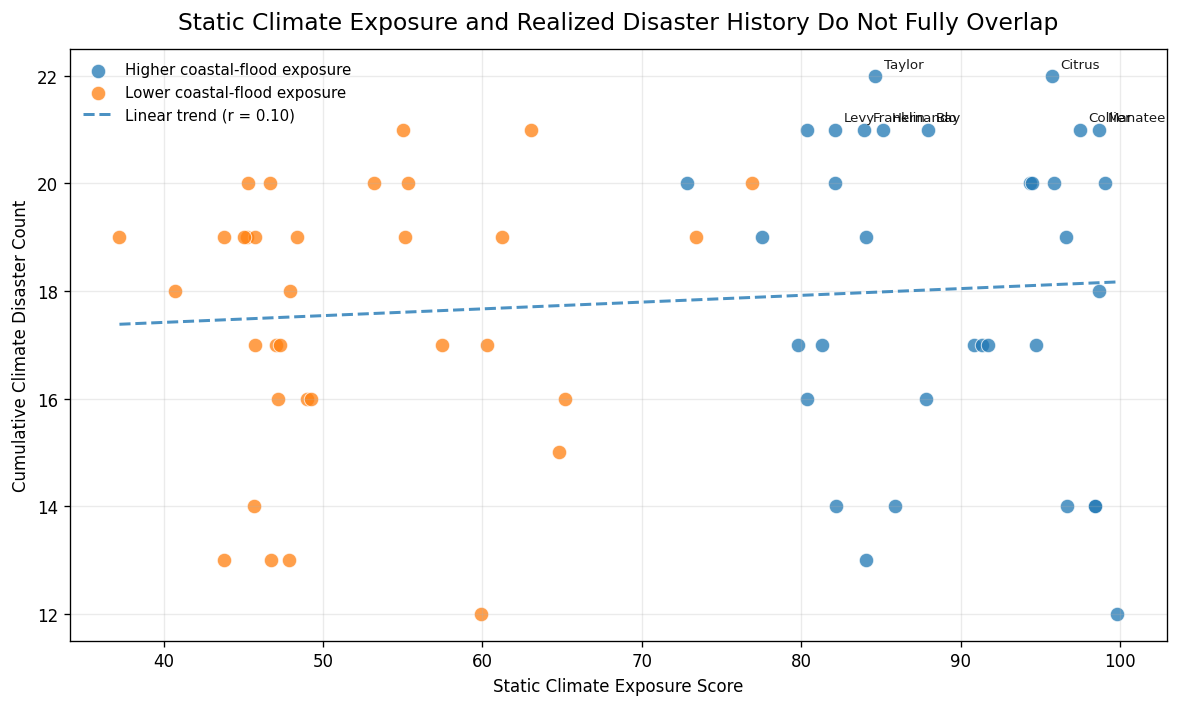

In [22]:
# ==================================================
# Step 5: Climate Exposure, Disaster History, and Insurance Losses
# Figure 5 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot scatter by coastal-flood exposure group

for group_name, group_df in county_climate_disaster.groupby("coastal_flood_exposure_group"):
    ax.scatter(
        group_df["climate_exposure_score"],
        group_df["cumulative_climate_disaster_count"],
        s=75,
        alpha=0.75,
        label=group_name,
        edgecolor="white",
        linewidth=0.6
    )


# Add linear trend line

plot_df = county_climate_disaster.dropna(
    subset=["climate_exposure_score", "cumulative_climate_disaster_count"]
)

x = plot_df["climate_exposure_score"]
y = plot_df["cumulative_climate_disaster_count"]

trend_coefficients = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend_coefficients)

ax.plot(
    x.sort_values(),
    trend_line(x.sort_values()),
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
    label=f"Linear trend (r = {climate_disaster_corr:.2f})"
)


# Annotate top counties by cumulative disaster count

annotation_counties = (
    county_climate_disaster
    .sort_values("cumulative_climate_disaster_count", ascending=False)
    .head(8)
)

for _, row in annotation_counties.iterrows():
    ax.annotate(
        row["RegionName"].replace(" County", ""),
        xy=(
            row["climate_exposure_score"],
            row["cumulative_climate_disaster_count"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9
    )


# Labels and formatting

ax.set_title(
    "Static Climate Exposure and Realized Disaster History Do Not Fully Overlap",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Static Climate Exposure Score")
ax.set_ylabel("Cumulative Climate Disaster Count")

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
save_figure("fig05_climate_exposure_vs_cumulative_disaster_count.png")
plt.show()

### Figure 5 Interpretation

* The scatterplot compares each county’s **static climate exposure score** with its **cumulative climate disaster count**.

* The correlation is very weak at **r = 0.096**, meaning static exposure and realized disaster history do not strongly move together.

* Some counties show both high exposure and high disaster history, including **Citrus County** with an exposure score of **95.70** and **22** cumulative climate disasters, and **Manatee County** with an exposure score of **98.67** and **21** disasters.

* However, some counties with lower coastal-flood exposure also experienced high disaster counts, such as **Jefferson County** with **21** disasters and **Gilchrist County** with **21** disasters.

* At the same time, some very high-exposure counties show lower cumulative disaster counts, including **Miami-Dade County** with an exposure score of **99.78** and **12** disasters, and **Monroe County** with an exposure score of **98.40** and **14** disasters.

* This figure’s main contribution is that **static climate exposure and realized disaster history are not interchangeable**. Disaster history adds a time-varying layer of information that is not fully captured by FEMA’s static risk scores.


### 5.2 NFIP Cumulative Claim Payments

This step maps cumulative NFIP claim payments to examine where flood-insurance losses are financially concentrated across Florida counties.

In [23]:
# ==================================================
# Step 5: Climate Exposure, Disaster History, and Insurance Losses
# Figure 6 Data Preparation
# ==================================================

# Create county-level NFIP insurance-loss summary

county_nfip_losses = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        nfip_cumulative_claim_payment=("nfip_cumulative_claim_payment", "max"),
        nfip_cumulative_claim_count=("nfip_cumulative_claim_count", "max"),
        nfip_total_claim_payment=("nfip_total_claim_payment", "sum"),
        nfip_claim_count=("nfip_claim_count", "sum"),
        nfip_recent_3yr_claim_payment=("nfip_recent_3yr_claim_payment", "max")
    )
)


# Create readable payment values for reporting and mapping

county_nfip_losses["nfip_cumulative_claim_payment_millions"] = (
    county_nfip_losses["nfip_cumulative_claim_payment"] / 1_000_000
)

county_nfip_losses["log_nfip_cumulative_claim_payment"] = np.log1p(
    county_nfip_losses["nfip_cumulative_claim_payment"]
)


# Merge with Florida county geometry

nfip_loss_map = florida_shapes.merge(
    county_nfip_losses,
    on="STCOFIPS",
    how="left"
)


print("NFIP cumulative claim payment map dataset created.")
print(f"Shape: {nfip_loss_map.shape}")
print(f"Missing NFIP cumulative claim payment values: {nfip_loss_map['nfip_cumulative_claim_payment'].isna().sum()}")
print(f"Counties with zero cumulative NFIP claim payments: {(nfip_loss_map['nfip_cumulative_claim_payment'] == 0).sum()}")


# Display counties with highest cumulative NFIP claim payments

display(
    county_nfip_losses
    .sort_values("nfip_cumulative_claim_payment", ascending=False)
    .head(10)
)


# Save table for reporting reference

save_table(
    county_nfip_losses,
    "eda_county_nfip_cumulative_claim_payment_summary.csv"
)

NFIP cumulative claim payment map dataset created.
Shape: (67, 28)
Missing NFIP cumulative claim payment values: 0
Counties with zero cumulative NFIP claim payments: 2


,STCOFIPS,RegionName,nfip_cumulative_claim_payment,nfip_cumulative_claim_count,nfip_total_claim_payment,nfip_claim_count,nfip_recent_3yr_claim_payment,nfip_cumulative_claim_payment_millions,log_nfip_cumulative_claim_payment
34,12071,Lee County,"3,878,871,800.6200","39,411.0000","3,878,871,800.6200","39,411.0000","3,808,978,824.7700","3,878.8718",22.0788
51,12103,Pinellas County,"3,565,829,110.6600","31,445.0000","3,565,829,110.6600","31,445.0000","3,501,584,429.0700","3,565.8291",21.9947
27,12057,Hillsborough County,"1,126,276,724.1100","12,614.0000","1,126,276,724.1100","12,614.0000","1,095,317,959.1300","1,126.2767",20.8422
10,12021,Collier County,"1,114,534,735.9000","12,816.0000","1,114,534,735.9000","12,816.0000","1,051,580,510.5100","1,114.5347",20.8317
57,12115,Sarasota County,"820,323,432.6200","9,861.0000","820,323,432.6200","9,861.0000","811,211,530.4100",820.3234,20.5252
39,12081,Manatee County,"621,365,987.8700","7,407.0000","621,365,987.8700","7,407.0000","604,686,922.1000",621.3660,20.2474
50,12101,Pasco County,"589,065,143.0300","7,666.0000","589,065,143.0300","7,666.0000","555,713,047.7700",589.0651,20.1940
63,12127,Volusia County,"531,585,130.9800","8,737.0000","531,585,130.9800","8,737.0000","465,573,461.3000",531.5851,20.0914
7,12015,Charlotte County,"461,155,716.8600","8,964.0000","461,155,716.8600","8,964.0000","456,401,720.5100",461.1557,19.9492
5,12011,Broward County,"370,567,774.0300","10,978.0000","370,567,774.0300","10,978.0000","288,089,104.8700",370.5678,19.7305


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_county_nfip_cumulative_claim_payment_summary.csv


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig06_nfip_cumulative_claim_payments_map.png


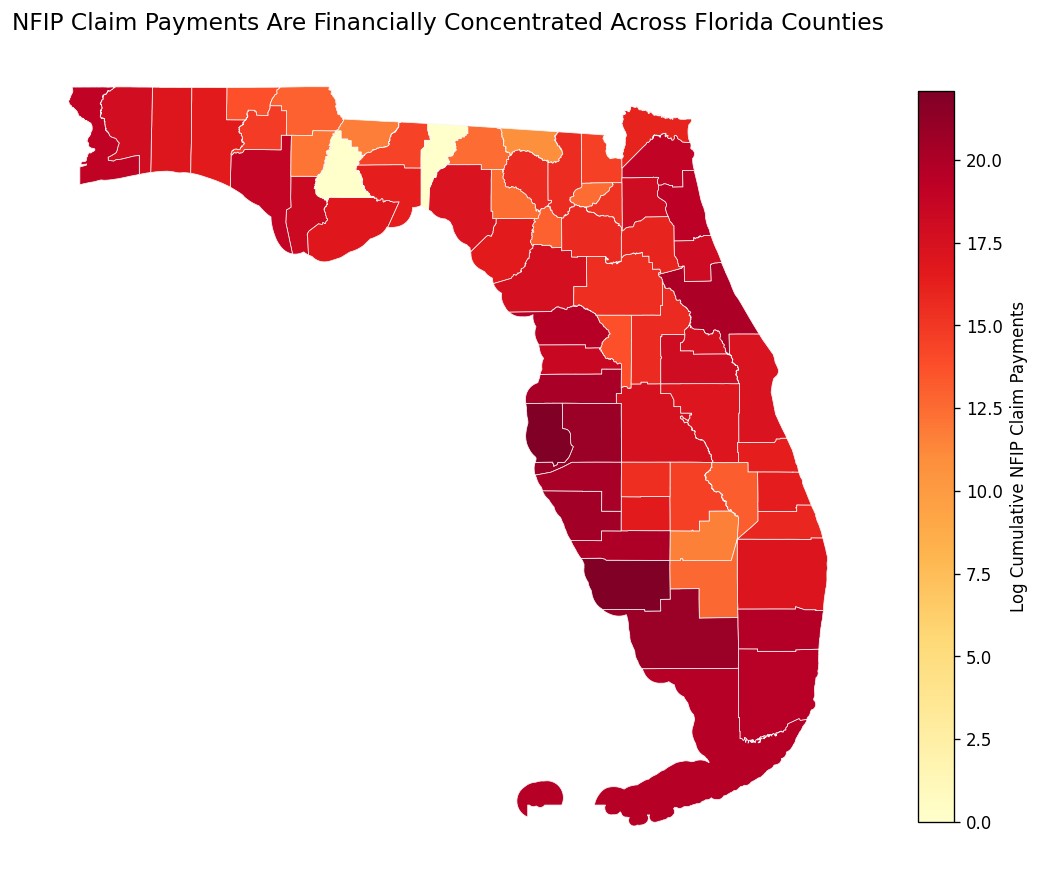

In [25]:
# ==================================================
# Step 5: Climate Exposure, Disaster History, and Insurance Losses
# Figure 6 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(9, 9))

nfip_loss_map.plot(
    column="log_nfip_cumulative_claim_payment",
    cmap="YlOrRd",
    linewidth=0.45,
    edgecolor="#F7F7F7",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Log Cumulative NFIP Claim Payments",
        "shrink": 0.7
    }
)

ax.set_title(
    "NFIP Claim Payments Are Financially Concentrated Across Florida Counties",
    fontsize=14,
    pad=12
)

ax.axis("off")

plt.tight_layout()
save_figure("fig06_nfip_cumulative_claim_payments_map.png")
plt.show()

### Figure 6 Interpretation

- The NFIP map shows that flood-insurance claim payments are highly concentrated across Florida counties.

- **Lee County** has the highest cumulative NFIP claim payments at about **$3.88 billion**, followed by **Pinellas County** at about **$3.57 billion**.

- **Hillsborough County** and **Collier County** also exceed **$1.1 billion** in cumulative NFIP claim payments.

- Other high-loss counties include **Sarasota, Manatee, Pasco, Volusia, Charlotte, and Broward**.

- The map shows a strong concentration of insurance-loss burden along the **Gulf Coast and Southwest Florida**, especially around **Lee, Pinellas, Hillsborough, Collier, Sarasota, Manatee, Pasco, and Charlotte**.

- Main contribution: this figure adds the **financial-loss burden layer**. Climate risk is not only about exposure scores or disaster counts; some counties carry much larger realized insurance-loss costs.


### Step 5 Key Takeaways

- Static climate exposure and disaster history are related only weakly, with a correlation of **r = 0.096**.

- Counties such as **Citrus, Manatee, Collier, Bay, Levy, Franklin, Hernando, Jefferson, and Gilchrist** show high cumulative disaster counts, but they do not all have the same exposure profile.

- NFIP losses are much more financially concentrated than disaster counts, with **Lee County** and **Pinellas County** alone exceeding **$3.5 billion** each in cumulative claim payments.

- The two figures serve different purposes: **Figure 5** shows a **risk-measurement mismatch**, while **Figure 6** shows a **financial-loss concentration pattern**.

- Step 5 strengthens the EDA narrative by separating three climate-risk signals: **static exposure**, **realized disaster history**, and **insurance-loss burden**.

## 6. Affordability and Market Stress

This section examines how housing affordability pressure changed over time across different Florida county groups.

### 6.1 Price-to-Income Ratio Trend by County Growth Group

This step creates data-driven county groups based on average annual housing price growth and compares their price-to-income ratio trends from 2011 to 2025.

In [26]:
# ==================================================
# Step 6: Affordability and Market Stress
# Figure 7 Data Preparation
# ==================================================

# Create county-level housing growth summary

county_growth_summary = (
    county_year_df
    .groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        avg_annual_price_growth_pct=("annual_price_growth_pct", "mean"),
        avg_price_to_income_ratio=("price_to_income_ratio", "mean"),
        avg_housing_price=("avg_annual_housing_price", "mean"),
        avg_coastal_flood_risk=("CFLD_RISKS", "mean"),
        avg_hurricane_risk=("HRCN_RISKS", "mean")
    )
)


# Create data-driven county growth groups using terciles

county_growth_summary["growth_group"] = pd.qcut(
    county_growth_summary["avg_annual_price_growth_pct"],
    q=3,
    labels=[
        "Lower-growth counties",
        "Moderate-growth counties",
        "Higher-growth counties"
    ]
)


# Merge growth groups back into county-year dataset

affordability_trend_df = county_year_df.merge(
    county_growth_summary[["STCOFIPS", "RegionName", "growth_group"]],
    on=["STCOFIPS", "RegionName"],
    how="left"
)


# Create annual affordability trend by county growth group

affordability_trend = (
    affordability_trend_df
    .groupby(["Year", "growth_group"], as_index=False, observed=True)
    .agg(
        avg_price_to_income_ratio=("price_to_income_ratio", "mean"),
        median_price_to_income_ratio=("price_to_income_ratio", "median"),
        avg_housing_price=("avg_annual_housing_price", "mean"),
        avg_median_household_income=("median_household_income", "mean"),
        county_count=("STCOFIPS", "nunique")
    )
)


print("Affordability trend dataset created.")
print(f"County growth summary shape: {county_growth_summary.shape}")
print(f"Affordability trend shape: {affordability_trend.shape}")
print(f"Missing growth groups: {affordability_trend_df['growth_group'].isna().sum()}")


# Display county group counts

display(
    county_growth_summary
    .groupby("growth_group", observed=True)
    .agg(
        county_count=("STCOFIPS", "nunique"),
        avg_annual_price_growth_pct=("avg_annual_price_growth_pct", "mean"),
        avg_price_to_income_ratio=("avg_price_to_income_ratio", "mean"),
        avg_coastal_flood_risk=("avg_coastal_flood_risk", "mean"),
        avg_hurricane_risk=("avg_hurricane_risk", "mean")
    )
    .reset_index()
)


# Display highest-growth counties for reporting reference

display(
    county_growth_summary
    .sort_values("avg_annual_price_growth_pct", ascending=False)
    .head(10)
)


# Save tables for reporting reference

save_table(
    county_growth_summary,
    "eda_county_growth_group_summary.csv"
)

save_table(
    affordability_trend,
    "eda_affordability_trend_by_growth_group.csv"
)

Affordability trend dataset created.
County growth summary shape: (67, 8)
Affordability trend shape: (45, 7)
Missing growth groups: 0


,growth_group,county_count,avg_annual_price_growth_pct,avg_price_to_income_ratio,avg_coastal_flood_risk,avg_hurricane_risk
0,Lower-growth counties,23,5.0939,3.5440,37.0522,91.8449
1,Moderate-growth counties,22,6.3811,4.0354,51.9818,94.1575
2,Higher-growth counties,22,7.4711,4.2338,54.8273,96.2017


,STCOFIPS,RegionName,avg_annual_price_growth_pct,avg_price_to_income_ratio,avg_housing_price,avg_coastal_flood_risk,avg_hurricane_risk,growth_group
24,12051,Hendry County,9.2013,3.4953,"154,947.6040",25.6000,94.2428,Higher-growth counties
55,12111,Saint Lucie County,9.1307,4.0638,"229,315.0414",65.2000,99.2073,Higher-growth counties
42,12086,Miami-Dade County,8.0260,5.7783,"318,826.6706",99.6000,99.9583,Higher-growth counties
48,12097,Osceola County,7.8589,4.2709,"240,178.9741",0.0000,94.1594,Higher-growth counties
46,12093,Okeechobee County,7.8526,3.5691,"161,002.2344",0.0000,93.5336,Higher-growth counties
5,12011,Broward County,7.7796,4.3609,"274,284.8928",97.0000,99.8331,Higher-growth counties
20,12043,Glades County,7.7053,3.8037,"148,245.0438",0.0000,87.6095,Higher-growth counties
43,12087,Monroe County,7.4840,9.7088,"736,500.2358",98.8000,97.9975,Higher-growth counties
47,12095,Orange County,7.3576,4.2120,"259,858.5266",0.0000,98.0392,Higher-growth counties
25,12053,Hernando County,7.3503,3.5918,"187,998.9016",74.2000,96.0784,Higher-growth counties


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_county_growth_group_summary.csv
Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_affordability_trend_by_growth_group.csv


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig07_price_to_income_ratio_trend_by_growth_group.png


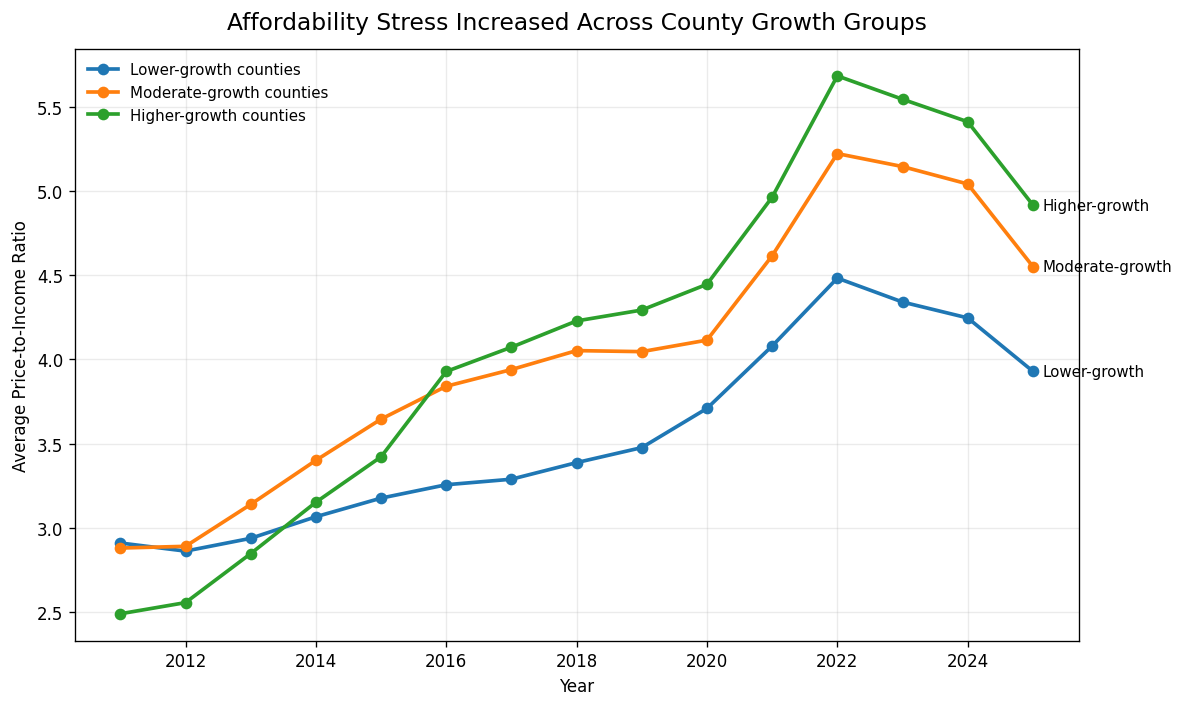

Affordability change summary:


,growth_group,2011,2025,absolute_change,percent_change
0,Lower-growth counties,2.9110,3.9300,1.0190,34.9880
1,Moderate-growth counties,2.8810,4.5510,1.6700,57.9630
2,Higher-growth counties,2.4910,4.9160,2.4250,97.3360


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_affordability_change_summary_by_growth_group.csv


In [27]:
# ==================================================
# Step 6: Affordability and Market Stress
# Figure 7 Visualization
# ==================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot price-to-income ratio trend for each county growth group

for group_name, group_df in affordability_trend.groupby("growth_group", observed=True):
    group_df = group_df.sort_values("Year")
    
    ax.plot(
        group_df["Year"],
        group_df["avg_price_to_income_ratio"],
        marker="o",
        linewidth=2.2,
        label=group_name
    )


# Create start-end affordability change summary for reporting

start_year = affordability_trend["Year"].min()
end_year = affordability_trend["Year"].max()

affordability_change_summary = (
    affordability_trend[
        affordability_trend["Year"].isin([start_year, end_year])
    ]
    .pivot(
        index="growth_group",
        columns="Year",
        values="avg_price_to_income_ratio"
    )
    .reset_index()
)

affordability_change_summary.columns.name = None

affordability_change_summary["absolute_change"] = (
    affordability_change_summary[end_year]
    - affordability_change_summary[start_year]
)

affordability_change_summary["percent_change"] = (
    affordability_change_summary["absolute_change"]
    / affordability_change_summary[start_year]
    * 100
)


# Add end-point labels

for group_name, group_df in affordability_trend.groupby("growth_group", observed=True):
    group_df = group_df.sort_values("Year")
    last_row = group_df[group_df["Year"] == end_year].iloc[0]
    
    ax.annotate(
        group_name.replace(" counties", ""),
        xy=(last_row["Year"], last_row["avg_price_to_income_ratio"]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=9,
        va="center"
    )


# Labels and formatting

ax.set_title(
    "Affordability Stress Increased Across County Growth Groups",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Year")
ax.set_ylabel("Average Price-to-Income Ratio")

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
save_figure("fig07_price_to_income_ratio_trend_by_growth_group.png")
plt.show()


print("Affordability change summary:")
display(
    affordability_change_summary.round(3)
)


# Save table for reporting reference

save_table(
    affordability_change_summary,
    "eda_affordability_change_summary_by_growth_group.csv"
)

### Figure 7 Interpretation

* The line chart shows that affordability stress increased across all county growth groups from **2011 to 2025**.

* Higher-growth counties had the lowest average price-to-income ratio in **2011** at **2.49**, but reached the highest level by **2025** at **4.92**.

* Lower-growth counties increased more moderately, from **2.91** in 2011 to **3.93** in 2025.

* Moderate-growth counties increased from **2.88** to **4.55** over the same period.

* The largest increase occurred in higher-growth counties, where the price-to-income ratio rose by **97.3%**.

* Main contribution: this figure shows the **affordability-pressure channel**. Strong housing-market growth can also intensify household stress when prices rise faster than incomes.


### Step 6 Key Takeaways

* Faster-growing counties show higher average affordability stress, with an average price-to-income ratio of **4.23** compared with **3.54** in lower-growth counties.

* Higher-growth counties also have higher average climate exposure, with coastal flood risk of **54.83** and hurricane risk of **96.20**.

* The top growth group includes counties such as **Hendry, Saint Lucie, Miami-Dade, Osceola, Okeechobee, Broward, Glades, Monroe, Orange, and Hernando**.

* By 2025, higher-growth counties had the highest affordability stress, even though they started with the lowest price-to-income ratio in 2011.

* Step 6 adds a separate narrative layer: housing growth is not only market strength; it can also create affordability pressure, especially when growth overlaps with climate-exposed counties.

## 7. Relationship Between Housing Signals and Vulnerability Stress

This section examines whether housing-market indicators are strongly connected to deeper vulnerability-stress indicators.

### 7.1 Focused Correlation Heatmap

This step creates a focused correlation matrix between housing signals and vulnerability-stress indicators to test whether prices and growth patterns can act as reliable proxies for climate, disaster, insurance-loss, social vulnerability, and resilience stress.

In [28]:
# ==================================================
# Step 7: Relationship Between Housing Signals and Vulnerability Stress
# Figure 8 Data Preparation
# ==================================================

# Create transformed variables for skewed indicators

correlation_df = county_year_df.copy()

correlation_df["log_annual_price_volatility"] = np.log1p(
    correlation_df["annual_price_volatility"]
)

correlation_df["log_nfip_cumulative_claim_payment"] = np.log1p(
    correlation_df["nfip_cumulative_claim_payment"]
)


# Define housing-market indicators

housing_signal_vars = [
    "avg_annual_housing_price",
    "annual_price_growth_pct",
    "appreciation_from_baseline_pct",
    "log_annual_price_volatility",
    "price_growth_acceleration",
    "price_to_income_ratio"
]


# Define vulnerability-stress indicators

vulnerability_stress_vars = [
    "CFLD_RISKS",
    "HRCN_RISKS",
    "cumulative_climate_disaster_count",
    "log_nfip_cumulative_claim_payment",
    "SOVI_SCORE",
    "RESL_SCORE"
]


# Create readable labels for visualization and reporting

variable_labels = {
    "avg_annual_housing_price": "Housing price",
    "annual_price_growth_pct": "Annual price growth",
    "appreciation_from_baseline_pct": "Baseline appreciation",
    "log_annual_price_volatility": "Price volatility",
    "price_growth_acceleration": "Growth acceleration",
    "price_to_income_ratio": "Price-to-income ratio",
    "CFLD_RISKS": "Coastal flood risk",
    "HRCN_RISKS": "Hurricane risk",
    "cumulative_climate_disaster_count": "Cumulative disasters",
    "log_nfip_cumulative_claim_payment": "NFIP claim payments",
    "SOVI_SCORE": "Social vulnerability",
    "RESL_SCORE": "Resilience"
}


# Compute focused correlation matrix

focused_corr = correlation_df[
    housing_signal_vars + vulnerability_stress_vars
].corr()


# Keep only vulnerability-stress indicators vs housing-market indicators

focused_corr_matrix = focused_corr.loc[
    vulnerability_stress_vars,
    housing_signal_vars
]


# Rename rows and columns for readability

focused_corr_matrix_labeled = focused_corr_matrix.rename(
    index=variable_labels,
    columns=variable_labels
)


print("Focused correlation matrix created.")
print(f"Shape: {focused_corr_matrix_labeled.shape}")
print(f"Missing values in selected variables: {correlation_df[housing_signal_vars + vulnerability_stress_vars].isna().sum().sum()}")


# Display correlation matrix

display(
    focused_corr_matrix_labeled.round(3)
)


# Save table for reporting reference

save_table(
    focused_corr_matrix_labeled.reset_index().rename(columns={"index": "vulnerability_stress_indicator"}),
    "eda_focused_housing_vulnerability_correlation_matrix.csv"
)

Focused correlation matrix created.
Shape: (6, 6)
Missing values in selected variables: 73


,Housing price,Annual price growth,Baseline appreciation,Price volatility,Growth acceleration,Price-to-income ratio
Coastal flood risk,0.3640,0.0270,0.0950,0.2510,-0.0130,0.3310
Hurricane risk,0.2970,0.0350,0.1200,0.2430,-0.0040,0.3150
Cumulative disasters,0.6090,0.0560,0.8340,0.2290,-0.3730,0.4880
NFIP claim payments,0.5320,0.2510,0.4620,0.3970,-0.1610,0.4880
Social vulnerability,-0.1770,0.0210,0.0200,-0.1030,-0.0080,0.0350
Resilience,0.2970,-0.0410,-0.0460,0.1410,0.0050,0.1820


Table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\eda\eda_focused_housing_vulnerability_correlation_matrix.csv


Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\eda\fig08_housing_signals_vs_vulnerability_stress_heatmap.png


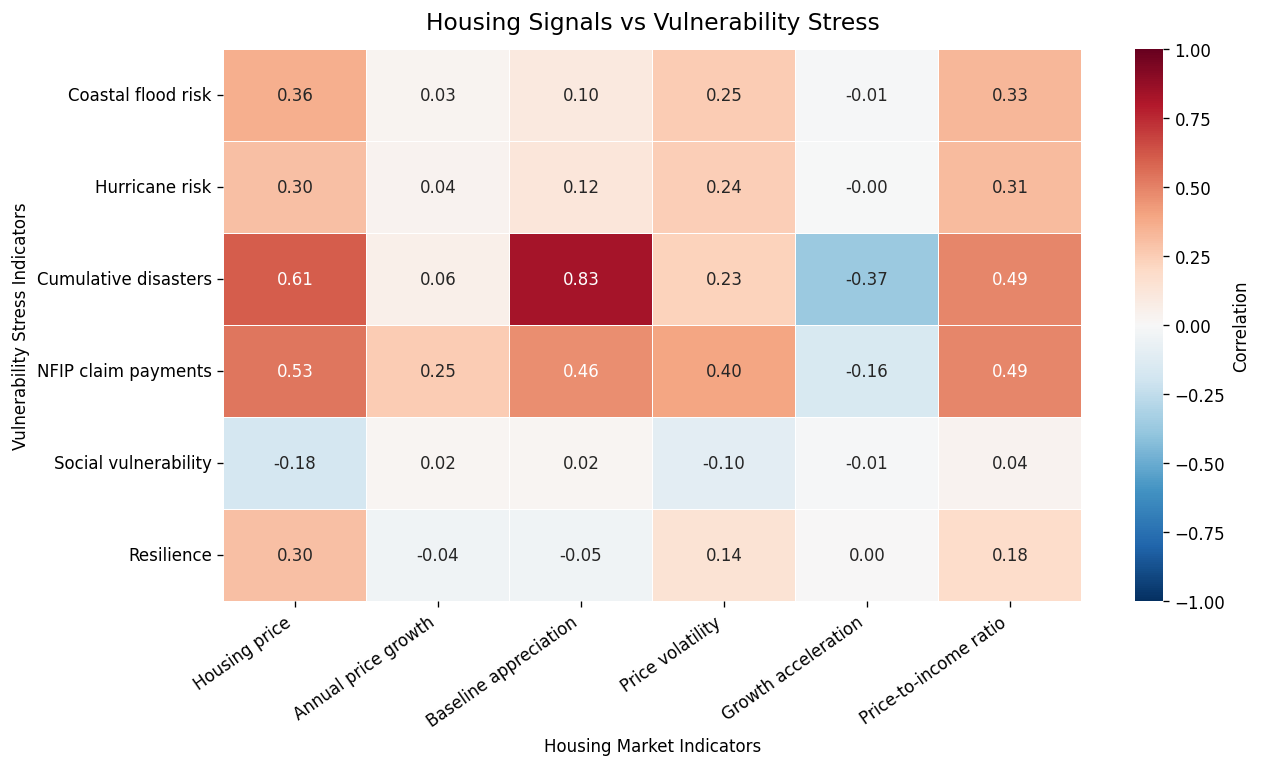

In [30]:
# ==================================================
# Step 7: Relationship Between Housing Signals and Vulnerability Stress
# Figure 8 Visualization
# ==================================================
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 6.5))

sns.heatmap(
    focused_corr_matrix_labeled,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Correlation"
    },
    ax=ax
)

ax.set_title(
    "Housing Signals vs Vulnerability Stress",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Housing Market Indicators")
ax.set_ylabel("Vulnerability Stress Indicators")

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
save_figure("fig08_housing_signals_vs_vulnerability_stress_heatmap.png")
plt.show()


### Figure 8 Interpretation

- The heatmap shows that housing-market indicators capture some vulnerability-stress dimensions, but not all of them.

- **Cumulative disasters** have the strongest relationship with **baseline appreciation** at **0.83** and a moderate relationship with **housing price** at **0.61**.

- **NFIP claim payments** are also moderately related to **housing price** at **0.53**, **baseline appreciation** at **0.46**, and **price-to-income ratio** at **0.49**.

- Climate exposure indicators show weaker-to-moderate relationships with housing signals. Coastal flood risk is correlated with **housing price** at **0.36** and **price-to-income ratio** at **0.33**.

- **Social vulnerability** is weakly related to almost all housing indicators, including **annual price growth** at **0.02** and **price-to-income ratio** at **0.04**.

- Main contribution: this figure shows that housing signals provide an **incomplete view of vulnerability stress**. Disaster and insurance-loss burdens are partly visible through market indicators, but social vulnerability is largely hidden from housing-price signals.

---

### Step 7 Key Takeaways

- Housing-market indicators do not reflect all vulnerability-stress dimensions equally.

- Disaster history and NFIP losses show the strongest links with housing prices, appreciation, and affordability stress.

- Social vulnerability is mostly disconnected from housing-market signals, suggesting that price growth does not reveal where socioeconomic stress is concentrated.

- Annual price growth has weak correlations with most stress indicators, including coastal flood risk, hurricane risk, cumulative disasters, and social vulnerability.

- Step 7 adds the final EDA evidence layer: market indicators are useful, but incomplete. They capture some financial and disaster-related stress, while missing important social vulnerability patterns.

## 8. EDA Summary and Transition to Vulnerability Scoring

This section summarizes the main EDA findings and explains how they motivate the construction of a climate-housing vulnerability score.

### 8.1 Main EDA Findings

* **Florida housing prices increased strongly over time.** The statewide average annual housing price rose from about **$123,821 in 2011** to **$329,862 in 2025**, showing that the market remained strong even around major hurricane years.

* **Housing growth was spatially uneven.** High-growth counties included coastal and metro markets such as **Miami-Dade, Broward, Monroe, Saint Lucie, and Orange**, but also inland and south-central counties such as **Hendry, Okeechobee, Glades, and Osceola**.

* **Social vulnerability and resilience showed different spatial patterns.** Counties such as **Highlands, Levy, De Soto, Hendry, Glades, Taylor, Hamilton, Okeechobee, Citrus, and Madison** combined high social vulnerability with lower resilience.

* **Socioeconomic vulnerability was concentrated in specific inland and rural counties.** The highest SOVI counties included **Jefferson, Gadsden, Highlands, Levy, De Soto, Hendry, Glades, Taylor, and Hamilton**.

* **Static climate exposure and disaster history did not fully overlap.** The correlation between static climate exposure and cumulative disaster count was only **r = 0.096**, showing that FEMA/NRI exposure scores and realized disaster history capture different signals.

* **NFIP insurance losses were highly concentrated.** **Lee County** and **Pinellas County** each exceeded **$3.5 billion** in cumulative NFIP claim payments, while **Hillsborough** and **Collier** each exceeded **$1.1 billion**.

* **Affordability stress increased fastest in higher-growth counties.** Higher-growth counties moved from the lowest price-to-income ratio in **2011** at **2.49** to the highest by **2025** at **4.92**, an increase of about **97.3%**.

* **Housing signals provided an incomplete view of vulnerability stress.** Disaster history and NFIP losses were partly visible through housing price and appreciation, but social vulnerability was weakly related to most housing indicators.

### 8.2 Transition to Vulnerability Scoring

* The EDA shows that no single variable captures the full climate-housing vulnerability pattern.

* Housing price growth identifies market pressure, but not necessarily socioeconomic vulnerability or resilience gaps.

* Static climate exposure identifies structural hazard risk, but not the full realized disaster history.

* Disaster declarations capture historical climate stress, but not the financial burden of insurance losses.

* NFIP claim payments reveal financial loss concentration, especially along the Gulf Coast and Southwest Florida.

* Affordability trends show that strong housing growth can increase household stress when prices rise faster than incomes.

* The correlation heatmap confirms that market indicators are useful but incomplete, especially because social vulnerability is largely hidden from price-based signals.

* Therefore, the next notebook constructs a **multi-dimensional climate-housing vulnerability score** that combines housing pressure, affordability stress, climate exposure, disaster history, socioeconomic vulnerability, resilience, insurance-loss burden, and spatial spillover indicators.
